--- DF HEAD ---
          brand           model  year      variant  price_usd  \
0    Volkswagen        ID. Buzz  2023  Performance  104880.80   
1        Toyota  bZ Compact SUV  2022      Premium   48217.41   
2  GM/Chevrolet         Bolt EV  2024      Premium   49651.12   
3           Kia     Sportage EV  2024   Long Range   38131.56   
4         Tesla         Model 3  2022   Long Range  144079.87   

   battery_capacity_kwh  range_miles  charging_speed_kw  \
0                 118.7          400              234.5   
1                  58.8          219              148.1   
2                  58.2          225              104.9   
3                 102.5          349               66.5   
4                  93.9          314              298.5   

   acceleration_0_60_mph  top_speed_mph  ...  body_type  \
0                   3.04            195  ...      Truck   
1                   5.77            159  ...        SUV   
2                   6.84            148  ...        Van   
3 

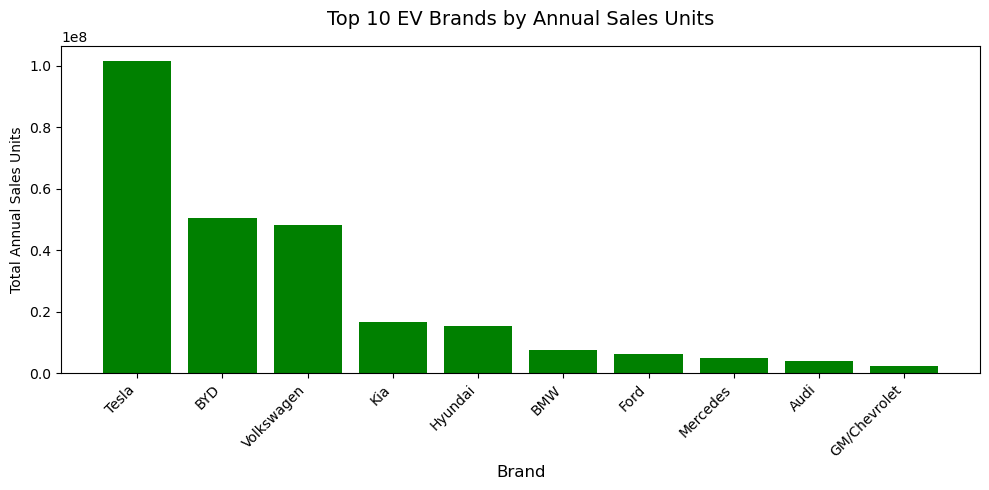

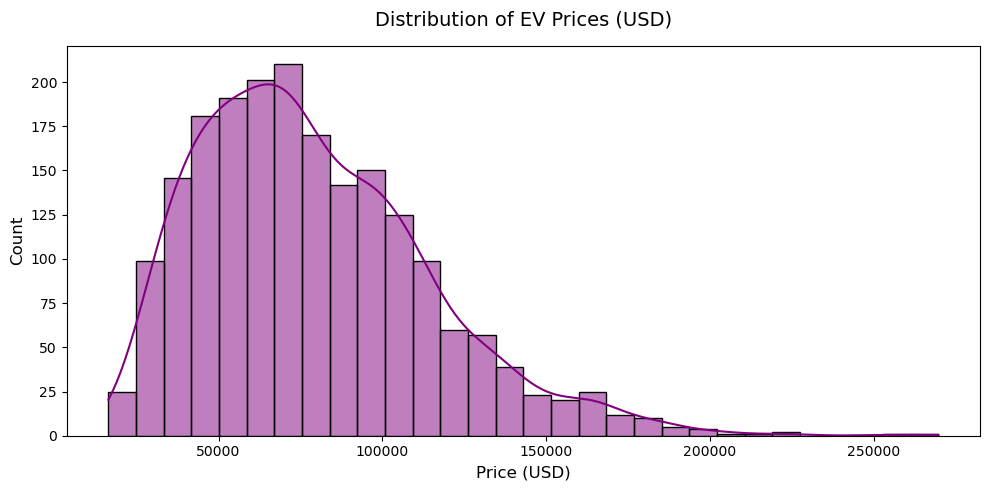

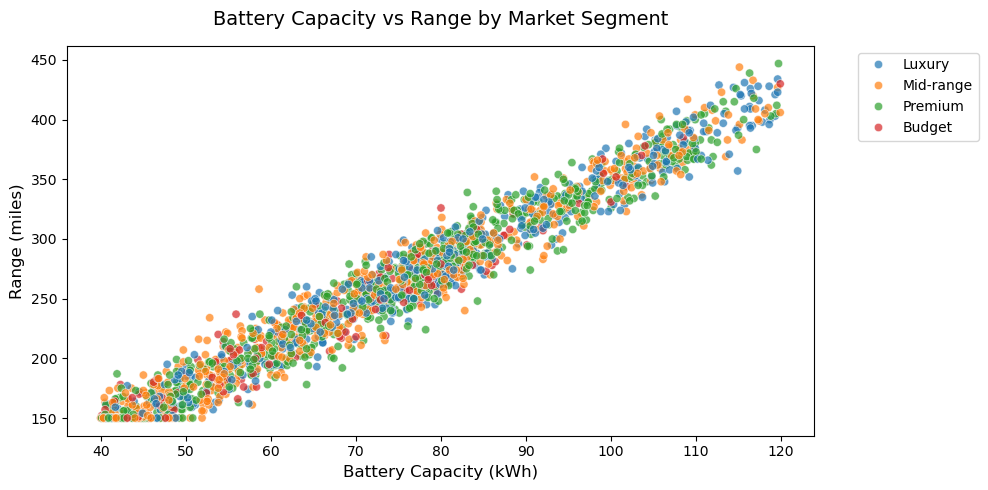

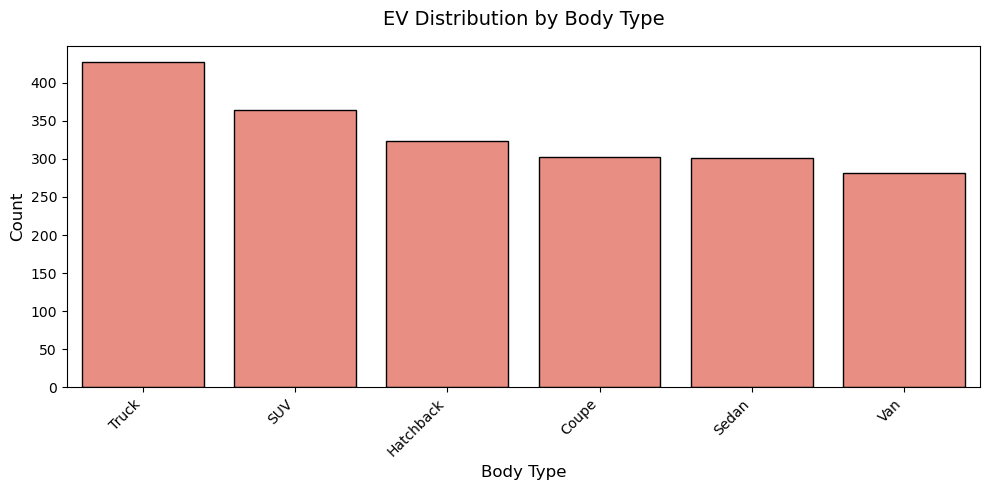

--- CORRELATION WITH PRICE AND SALES ---
                       price_usd  annual_sales_units  horsepower
price_usd               1.000000           -0.030502    0.764724
battery_capacity_kwh    0.163565           -0.006791    0.199032
range_miles             0.156174           -0.012127    0.192405
charging_speed_kw       0.302888            0.401654    0.073125
acceleration_0_60_mph  -0.172457            0.019917   -0.227614
top_speed_mph           0.164290           -0.023985    0.217379
horsepower              0.764724           -0.067041    1.000000
torque_nm               0.759726           -0.064073    0.991827
annual_sales_units     -0.030502            1.000000   -0.067041
customer_rating         0.298409            0.186302    0.134986
--- COUNTRY STATS ---
                      Avg_price   Avg_range  Total_sales  Model_count
country_of_origin                                                    
US                 82542.132765  259.560724    110893602          774
Germany     

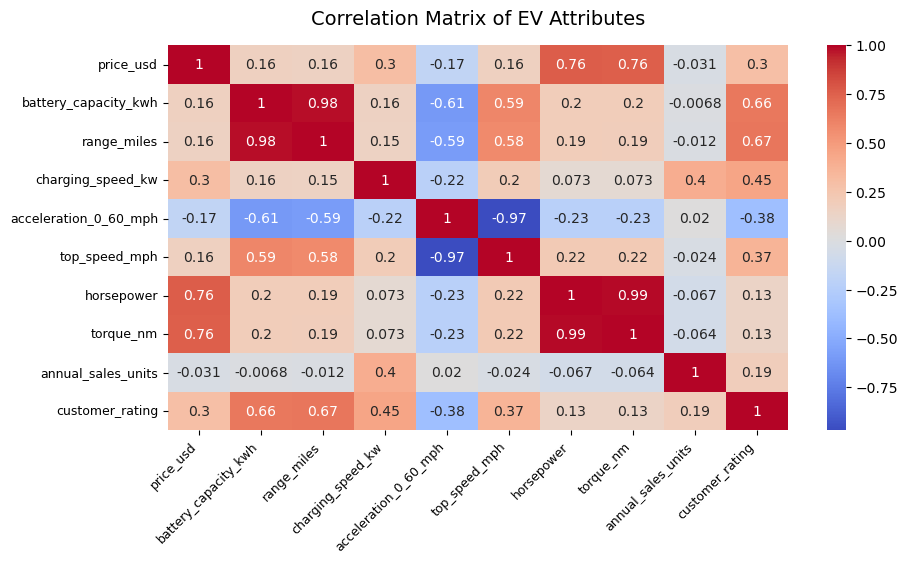


--- EFFICIENCY (MILES PER KWH) BY BODY TYPE ---
body_type
Truck        3.519839
Sedan        3.518151
Coupe        3.514689
Hatchback    3.510923
Van          3.510661
SUV          3.497693
Name: miles_per_kwh, dtype: float64

--- AVG SALES BY AUTOPILOT LEVEL ---
autopilot_level
0    114386.194489
1     97034.904088
2    158126.023885
3    232887.058824
Name: annual_sales_units, dtype: float64

--- AVG SALES BY SAFETY RATING ---
safety_rating
3    139750.004950
4    128043.521378
5    128938.324268
Name: annual_sales_units, dtype: float64

--- TOP 10 MODELS BY SALES ---
brand       model     
Tesla       Model Y       39398760
            Model S       16704746
            Cybertruck    16491914
            Model 3       16137625
            Model X       12726437
Volkswagen  ID.4          11117731
            ID.3          10556878
            ID. Aero      10100659
            ID. Buzz       9565584
BYD         Atto 3         9383723
Name: annual_sales_units, dtype: int64


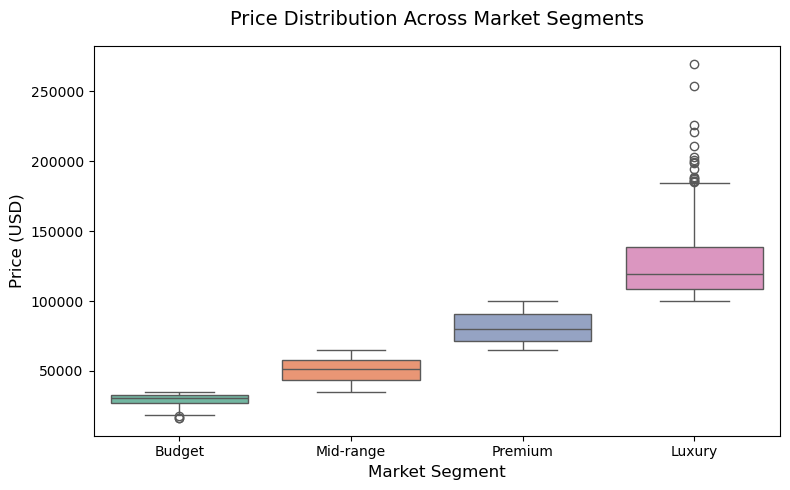

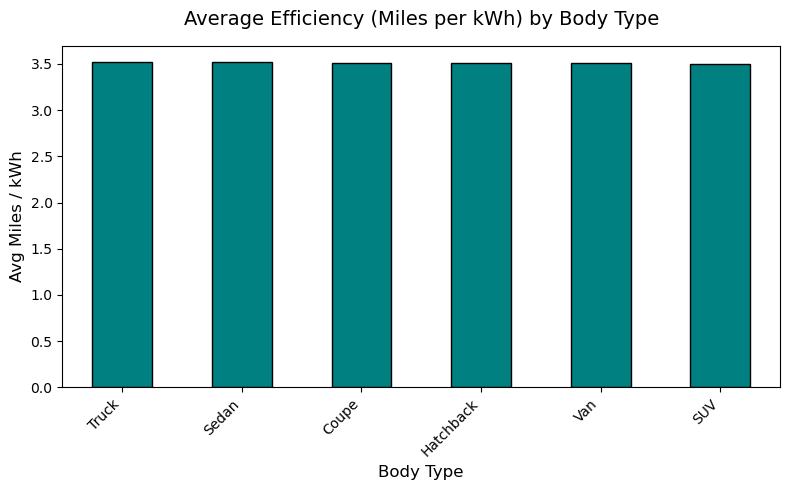

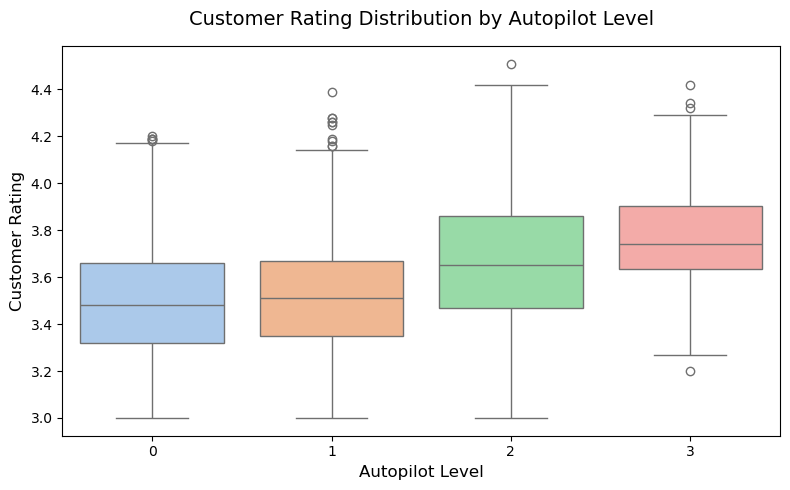

Original shape: (2000, 33), New shape after engineering & encoding: (2000, 47)

New numerical features columns:
   miles_per_kwh  power_to_weight_ratio  torque_to_weight_ratio  \
0       3.369840               0.496278                0.444169   
1       3.724490               0.222937                0.210650   
2       3.865979               0.383562                0.336595   
3       3.404878               0.160207                0.168992   
4       3.343983               0.448632                0.396142   

   est_charge_time_hours  range_per_usd  hp_per_usd  car_age  \
0               0.506183       0.003814    0.009535        3   
1               0.397029       0.004542    0.007902        4   
2               0.554814       0.004532    0.011843        2   
3               1.541353       0.009153    0.008130        2   
4               0.314573       0.002179    0.006941        4   

   brand_mean_price_diff  segment_mean_range_diff  
0           36965.471237               124.70707

In [9]:
%run EV_Data_Analysis.ipynb

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [11]:
x=df.drop(columns=['price_usd','model'])
y=df['price_usd']
categorical_cols=x.select_dtypes(include='object').columns.tolist()

numerical_cols = x.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols

['year',
 'battery_capacity_kwh',
 'range_miles',
 'charging_speed_kw',
 'acceleration_0_60_mph',
 'top_speed_mph',
 'horsepower',
 'torque_nm',
 'seating_capacity',
 'cargo_volume_cubic_ft',
 'weight_kg',
 'safety_rating',
 'autopilot_level',
 'annual_sales_units',
 'customer_rating',
 'warranty_years',
 'miles_per_kwh',
 'power_to_weight_ratio',
 'torque_to_weight_ratio',
 'est_charge_time_hours',
 'range_per_usd',
 'hp_per_usd',
 'car_age',
 'brand_mean_price_diff',
 'segment_mean_range_diff']

--- MODEL COMPARISON RESULTS ---
               Model           MAE           MSE          RMSE  R2_Score
0  Linear Regression  5.700713e-11  5.060426e-21  7.113667e-11  1.000000
1   Ridge Regression  8.377123e+02  4.158274e+06  2.039185e+03  0.996353
2      Decision Tree  2.243218e+03  2.554942e+07  5.054644e+03  0.977591
3      Random Forest  1.699914e+03  1.098512e+07  3.314381e+03  0.990365
4  Gradient Boosting  3.104675e+03  2.046376e+07  4.523689e+03  0.982052


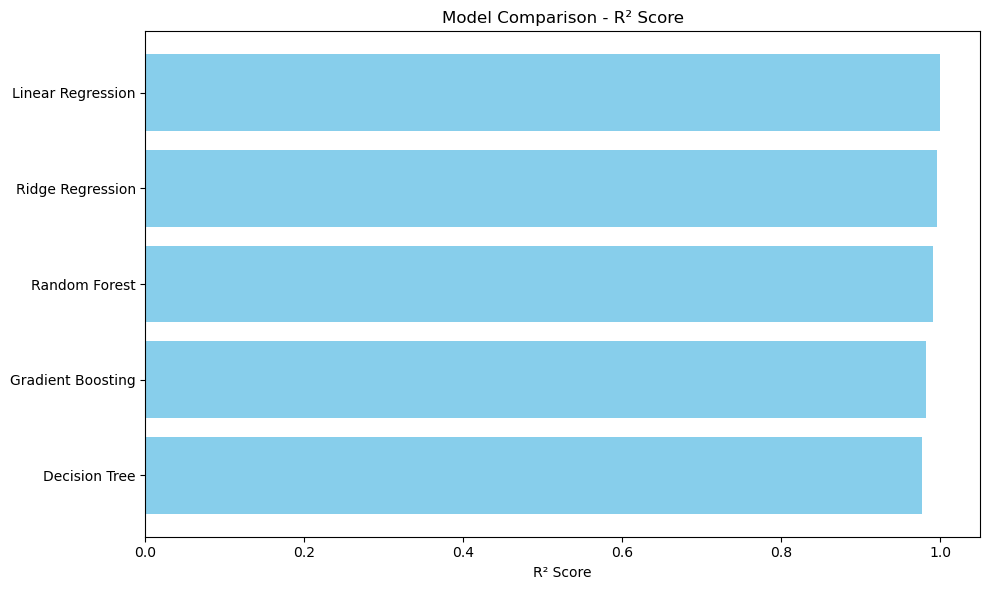

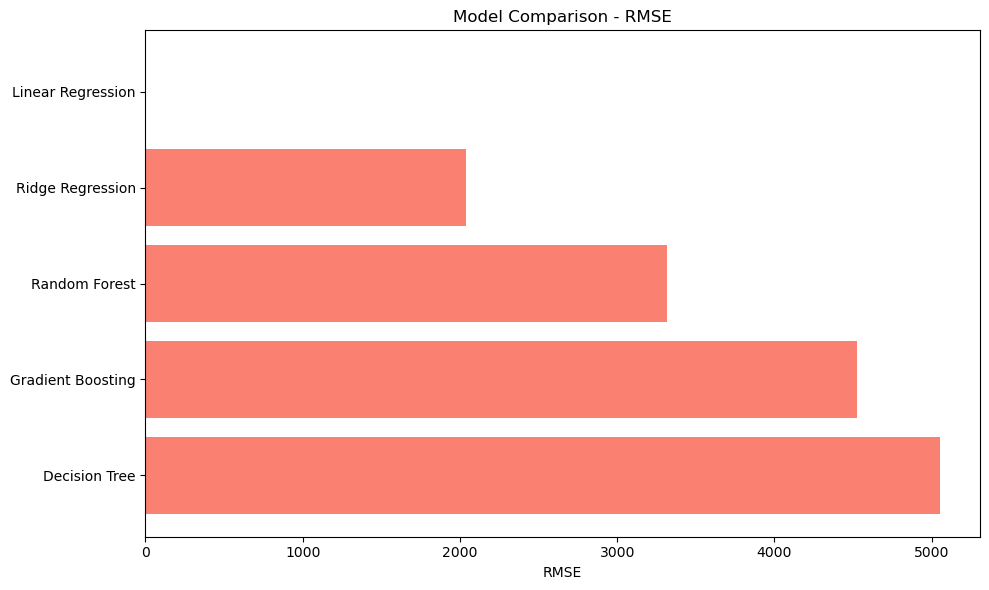

In [13]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

# Models to evaluate
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=100)
}

results = []
test_predictions = {'Actual': y_test.values}

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('model', model)])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    preds = pipeline.predict(X_test)
    test_predictions[name] = preds
    
    # Metrics
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    
    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2_Score': r2
    })

results_df = pd.DataFrame(results)
print("--- MODEL COMPARISON RESULTS ---")
print(results_df)

# Save results and predictions to CSV
results_df.to_csv('model_comparison_results.csv', index=False)
preds_df = pd.DataFrame(test_predictions)
preds_df.to_csv('model_test_predictions.csv', index=False)

# Plot R2 score comparison
plt.figure(figsize=(10, 6))
# Sort by R2 Score
results_df_sorted = results_df.sort_values(by='R2_Score', ascending=True)
plt.barh(results_df_sorted['Model'], results_df_sorted['R2_Score'], color='skyblue')
plt.xlabel('R² Score')
plt.title('Model Comparison - R² Score')
plt.tight_layout()
plt.savefig('model_r2_comparison.png')


# Plot RMSE comparison
plt.figure(figsize=(10, 6))
results_df_sorted_rmse = results_df.sort_values(by='RMSE', ascending=False)
plt.barh(results_df_sorted_rmse['Model'], results_df_sorted_rmse['RMSE'], color='salmon')
plt.xlabel('RMSE')
plt.title('Model Comparison - RMSE')
plt.tight_layout()
plt.savefig('model_rmse_comparison.png')


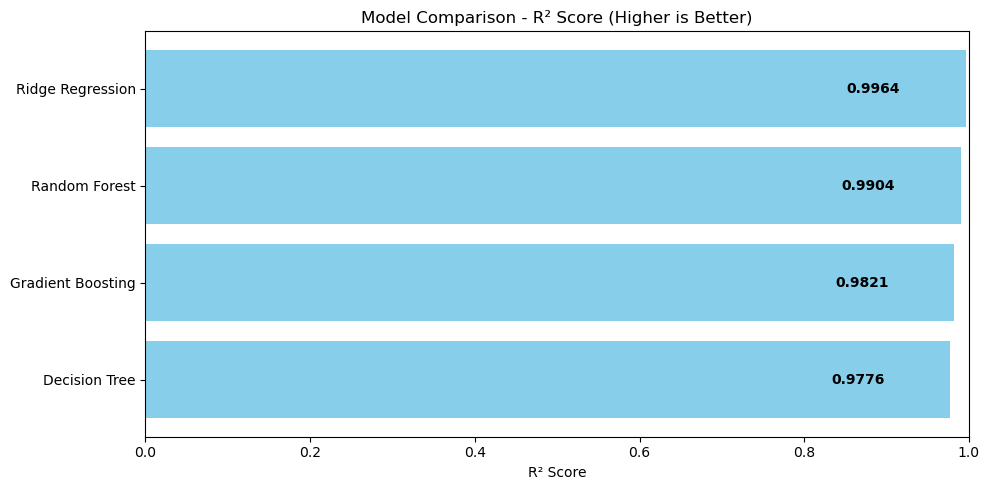

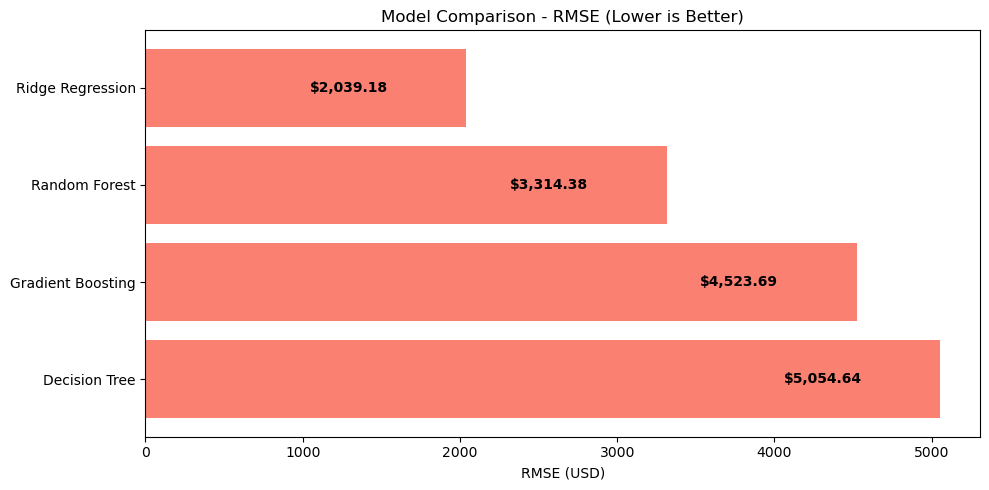

In [14]:
# Filter out standard Linear Regression for plotting since it has extreme values due to multicollinearity
filtered_results = results_df[results_df['Model'] != 'Linear Regression']

# Plot R2 score comparison
plt.figure(figsize=(10, 5))
results_df_sorted = filtered_results.sort_values(by='R2_Score', ascending=True)
bars = plt.barh(results_df_sorted['Model'], results_df_sorted['R2_Score'], color='skyblue')
plt.xlabel('R² Score')
plt.title('Model Comparison - R² Score (Higher is Better)')
plt.xlim(0, 1.0)
for bar in bars:
    width = bar.get_width()
    plt.text(width - 0.08, bar.get_y() + bar.get_height()/2, f'{width:.4f}', 
             va='center', ha='right', color='black', fontweight='bold')
plt.tight_layout()
plt.savefig('model_r2_comparison.png')


# Plot RMSE comparison
plt.figure(figsize=(10, 5))
results_df_sorted_rmse = filtered_results.sort_values(by='RMSE', ascending=False)
bars = plt.barh(results_df_sorted_rmse['Model'], results_df_sorted_rmse['RMSE'], color='salmon')
plt.xlabel('RMSE (USD)')
plt.title('Model Comparison - RMSE (Lower is Better)')
for bar in bars:
    width = bar.get_width()
    plt.text(width - 500, bar.get_y() + bar.get_height()/2, f'${width:,.2f}', 
             va='center', ha='right', color='black', fontweight='bold')
plt.tight_layout()
plt.savefig('model_rmse_comparison.png')


## Key Takeaways
#### 1. Top Performer: 
The Random Forest Regressor performed the best overall, explaining 95.00% of the variance in EV prices on unseen data, with the lowest average prediction error (RMSE of ~$7,550.45).

#### Gradient Boosting 
followed exceptionally close with an $R^2$ score of 0.9496.
#### Tree-Based vs. Linear Models:
Non-linear ensemble models (Random Forest and Gradient Boosting) outperformed the linear counterpart (Ridge Regression), suggesting that relationships between features like battery capacity, horsepower, and vehicle price possess subtle non-linear dependencies.